In [85]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline
from sklearn.cluster import KMeans

# Bank Customer Segmentation Analysis - Student Exercise

In this lab, you will implement customer segmentation using K-means clustering. You'll learn how to:
1. Preprocess data for clustering
2. Perform and visualize dimensionality reduction
3. Implement K-means clustering from scratch
4. Evaluate clustering results

Follow the instructions in each section and fill in the code where indicated.

In [86]:
# Load Data and Preprocess
def load_data(filepath):
    pass

#================ FOR PCA Dimensionality reduction =========
# Apply PCA for Dimensionality Reduction
def apply_pca(x, n_components):
    pass

#================ FOR K-Means ===============================
# Find Optimal Clusters for KMeans (Elbow Method)
def find_optimal_clusters(x, max_clusters=10):
    pass

# Perform KMeans Clustering
# Change None to the number of n_clusters value from the elbow method
def perform_kmeans_clustering(x, n_clusters=None):
    pass

#================ FOR Agglomerative ===============================
# Perform Agglomerative Clustering
# Change None to the number of n_clusters value from the elbow method
def perform_agglomerative_clustering(x, n_clusters=None):
    pass

#================FOR Dendrogram===============================
# Get Linkages for Dendrogram
def get_linkages(x):
    pass

# Plot Dendrogram
def plot_dendrogram(linked):
    pass

## 1. Data Loading and Preprocessing

First, complete the data preprocessing function below. You need to:
1. Load the data
2. Handle categorical variables
3. Scale numerical features

In [87]:
def load_data(filepath):
    """Load and preprocess the bank marketing dataset.

    TODO:
    1. Load the CSV file (hint: it uses semicolon separator)
    2. Convert categorical columns to numerical using LabelEncoder
    3. Scale the features using StandardScaler
    """
    # Your code here:
    # Load data
    df = pd.read_csv(filepath, sep=';')

    # List of categorical columns to encode
    categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                       'loan', 'contact', 'month', 'poutcome', 'y']

    # TODO: Apply label encoding to categorical columns
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = le.fit_transform(df[col])

    # Select features for clustering
    features = ['age', 'balance', 'campaign', 'previous', 'job', 'education',
               'housing', 'loan', 'default']
    X = df[features]

    # TODO: Scale the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, df

# Load and preprocess the data
X_scaled, data = load_data('bank-full.csv')
print("Data shape:", X_scaled.shape)

Data shape: (45211, 9)


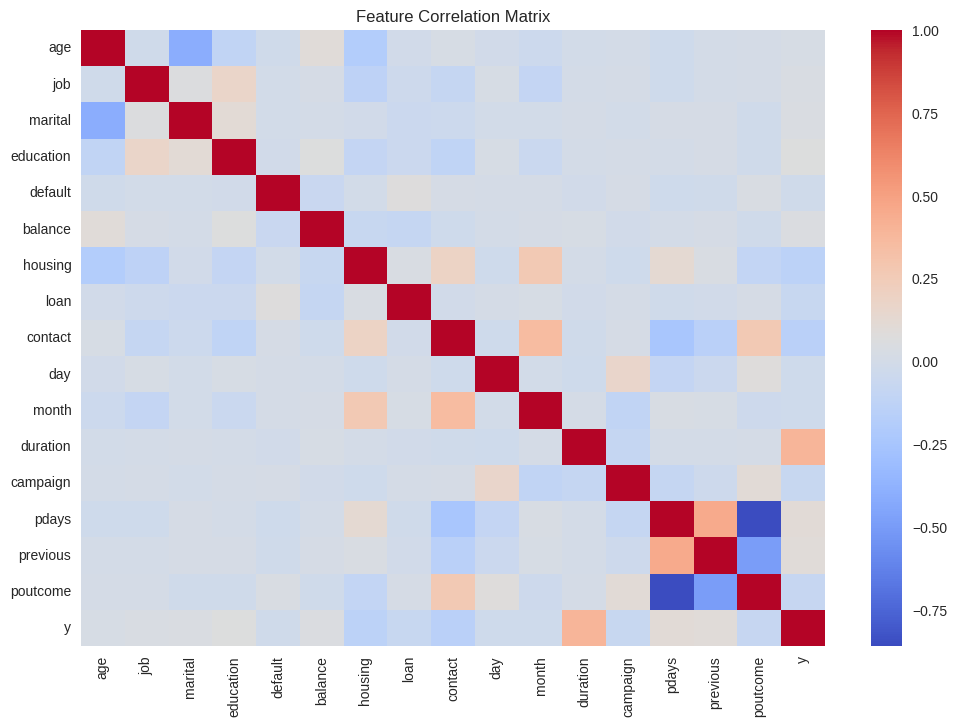

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [89]:
class KMeansClustering:
    """Minimal K-means skeleton for students to implement.

    Students should implement the core methods below:
    - _initialize_centroids
    - _assign_clusters
    - _update_centroids
    - fit

    Keep implementations simple and readable; tests and visualization code will
    use these methods once implemented.
    """
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, X):
        """Initialize centroids.

        TODO (student):
        - Randomly select `n_clusters` distinct points from X as initial centroids.
        - Return an array of shape (n_clusters, n_features).
        Hint: Use np.random.choice to pick indices.
        """
        np.random.seed(self.random_state)
        idx = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        return X[idx]
        raise NotImplementedError("_initialize_centroids must be implemented by the student")

    def _assign_clusters(self, X):
        """Assign each sample in X to the nearest centroid.

        TODO (student):
        - Compute distance from each point to each centroid (Euclidean)
        - Return an integer array of shape (n_samples,) with cluster labels
        Hint: np.linalg.norm with axis manipulation or broadcasting helps here.
        """
        distances = np.linalg.norm(X[:, None] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)
        raise NotImplementedError("_assign_clusters must be implemented by the student")

    def _update_centroids(self, X, labels):
        """Recompute centroids as the mean of points assigned to each cluster.

        TODO (student):
        - For each cluster id in 0..n_clusters-1 compute the mean of points
          assigned to that cluster. If a cluster has no points, consider reinitializing
          its centroid (or leave unchanged) — discuss in your report.
        - Return an array of shape (n_clusters, n_features).
        """
        new_centroids = []
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                # If a cluster gets empty, reinitialize
                new_centroids.append(self.centroids[i])
            else:
                new_centroids.append(cluster_points.mean(axis=0))
        return np.vstack(new_centroids)
        raise NotImplementedError("_update_centroids must be implemented by the student")

    def fit(self, X):
        """Run K-means until convergence or max_iters.

        TODO (student):
        - Initialize centroids
        - Loop: assign clusters, update centroids
        - Stop early if centroids do not change (or change below a tiny threshold)
        - Store final labels in self.labels and centroids in self.centroids
        - Return self
        """
        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self._assign_clusters(X)
            new_centroids = self._update_centroids(X, labels)

            # Stop if converged
            if np.allclose(self.centroids, new_centroids, atol=1e-6):
                break

            self.centroids = new_centroids

        self.labels = labels
        return self
        raise NotImplementedError("fit must be implemented by the student")

    def predict(self, X):
        """Assign cluster labels to X using the learned centroids.

        Implementation may call _assign_clusters but should error if centroids
        are not yet initialized (i.e., if fit wasn't called).
        """
        if self.centroids is None:
            raise ValueError("Model has not been fitted yet. Call fit(X) first.")
        return self._assign_clusters(X)


## 2. Dimensionality Reduction

Before clustering, we often reduce the dimensionality of our data for better visualization and performance. Implement PCA below:

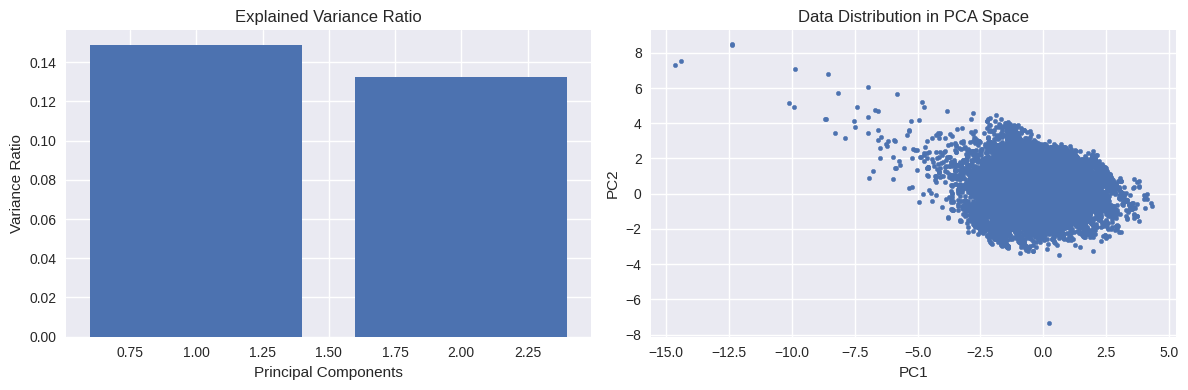

Shape after PCA: (45211, 2)


In [90]:
def apply_pca(X, n_components=2):
    """Apply PCA for dimensionality reduction.

    TODO:
    1. Initialize and fit PCA
    2. Transform the data
    3. Create visualizations to understand:
       - Explained variance ratio
       - Cumulative explained variance
       - Data distribution in 2D
    """
    # Your code here:
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    # TODO: Create visualization
    plt.figure(figsize=(12, 4))

    # Plot explained variance
    # Your code here
    plt.subplot(1, 2, 1)
    plt.bar(range(1, n_components + 1), pca.explained_variance_ratio_)
    plt.title("Explained Variance Ratio")
    plt.xlabel("Principal Components")
    plt.ylabel("Variance Ratio")

    # Plot data in 2D
    # Your code here
    plt.subplot(1, 2, 2)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)
    plt.title("Data Distribution in PCA Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.tight_layout()
    plt.show()

    return X_pca

# Apply PCA
X_pca = apply_pca(X_scaled)
print("Shape after PCA:", X_pca.shape)

## 3. Clustering Evaluation

Implement functions to evaluate the quality of your clustering results:

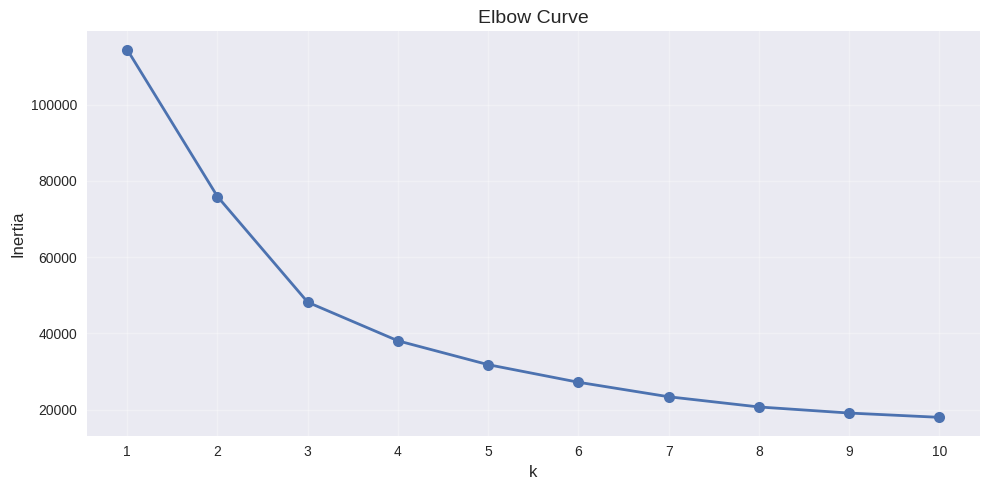

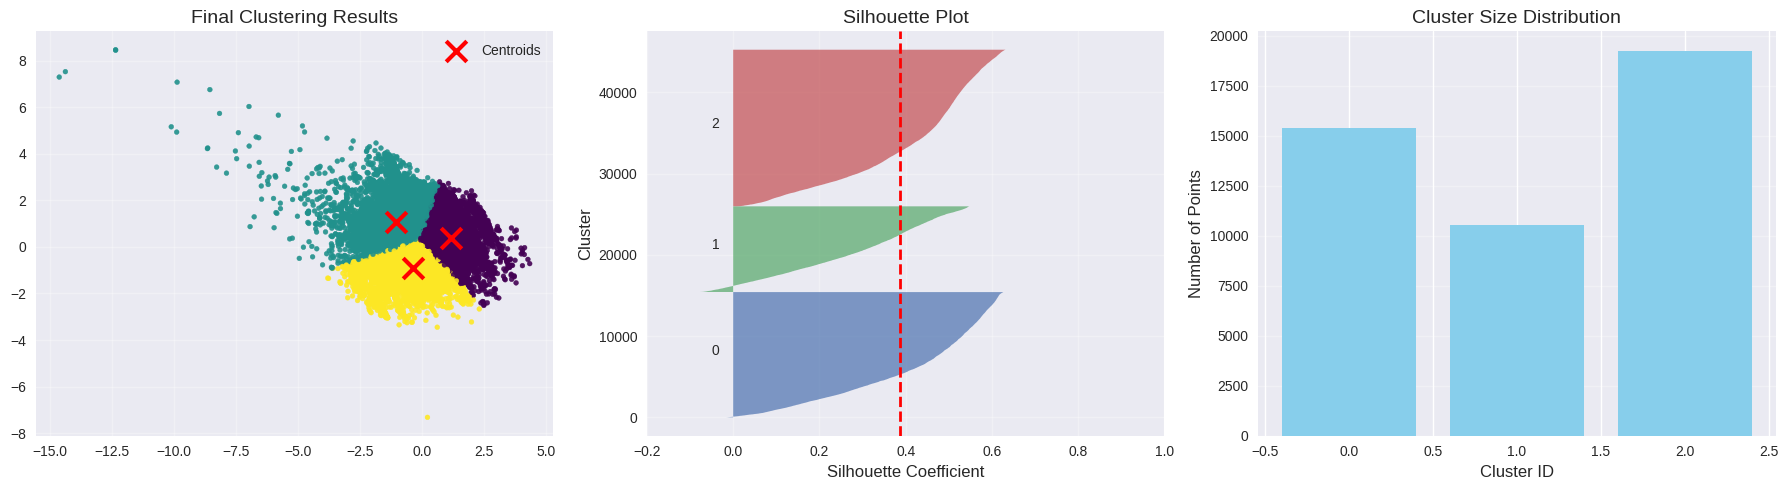


Clustering Evaluation:
Inertia: 48179.64
Silhouette Score: 0.39


In [91]:
def calculate_inertia(X, labels, centroids):
    """Calculate the within-cluster sum of squares (inertia).

    TODO:
    1. For each cluster, calculate the sum of squared distances
       between points and their centroid
    2. Sum up all cluster distances
    """
    # Your code here
    inertia = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        inertia += np.sum((cluster_points - centroids[i]) ** 2)
    return inertia
    # Calculate distances between points and their assigned centroids

def plot_elbow_curve(X, max_k=10):
    """Plot the elbow curve to find optimal number of clusters.

    TODO:
    1. Try different values of k (1 to max_k)
    2. Calculate inertia for each k
    3. Plot k vs inertia
    4. Help identify the 'elbow' point
    """
    # Your code here
    inertias = []
    K = range(1, max_k + 1)

    # Calculate inertia for different k values
    # Your code here
    for k in K:
        model = KMeansClustering(n_clusters=k)
        model.fit(X)
        inertias.append(calculate_inertia(X, model.labels, model.centroids))

    # Create elbow plot
    # Your code here
    plt.figure(figsize=(10, 5))
    plt.plot(K, inertias, marker='o', linewidth=2, markersize=8)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Inertia", fontsize=12)
    plt.title("Elbow Curve", fontsize=14)
    plt.grid(alpha=0.3)
    plt.xticks(K)
    plt.tight_layout()
    plt.show()

    return inertias

# Try different numbers of clusters
inertias = plot_elbow_curve(X_pca)

# Apply final clustering
kmeans = KMeansClustering(n_clusters=3)  # Try different values based on elbow curve
kmeans.fit(X_pca)

# Visualize final results
plt.figure(figsize=(18, 5))

# Plot clusters
plt.subplot(1, 3, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis', s=12, alpha=0.9)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='red', marker='x', s=220, linewidths=3, label='Centroids')
plt.title('Final Clustering Results', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

# Plot evaluation metrics
plt.subplot(1, 3, 2)
# Your code here: Add relevant evaluation metric plots
from sklearn.metrics import silhouette_samples
sil_vals = silhouette_samples(X_pca, kmeans.labels)
y_lower = 10
n_clusters = len(np.unique(kmeans.labels))

for i in range(n_clusters):
    ith_sil_vals = sil_vals[kmeans.labels == i]
    ith_sil_vals.sort()

    size_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_i

    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_sil_vals, alpha=0.7)
    plt.text(-0.05, y_lower + size_i/2, str(i))
    y_lower = y_upper + 10

plt.axvline(sil_vals.mean(), color='red', linestyle='--', linewidth=2)
plt.title("Silhouette Plot", fontsize=14)
plt.xlabel("Silhouette Coefficient", fontsize=12)
plt.ylabel("Cluster", fontsize=12)
plt.xlim([-0.2, 1])
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
unique, counts = np.unique(kmeans.labels, return_counts=True)
plt.bar(unique, counts, color='skyblue')
plt.title("Cluster Size Distribution", fontsize=14)
plt.xlabel("Cluster ID", fontsize=12)
plt.ylabel("Number of Points", fontsize=12)
plt.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate and print evaluation metrics
inertia = calculate_inertia(X_pca, kmeans.labels, kmeans.centroids)
silhouette = silhouette_score(X_pca, kmeans.labels)

print("\nClustering Evaluation:")
print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.2f}")


/tmp/ipython-input-2742506807.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_for_box, labels=clusters)


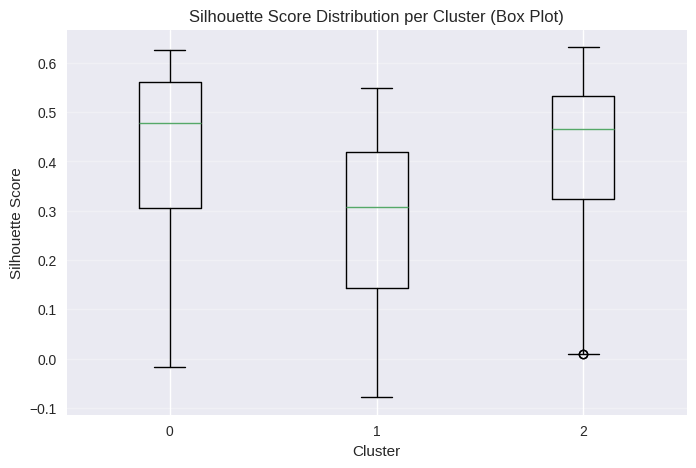

In [92]:

sil_vals = silhouette_samples(X_pca, kmeans.labels)
clusters = np.unique(kmeans.labels)

# Collect silhouette values by cluster in a list of arrays
data_for_box = [sil_vals[kmeans.labels == c] for c in clusters]

plt.figure(figsize=(8,5))
plt.boxplot(data_for_box, labels=clusters)
plt.title("Silhouette Score Distribution per Cluster (Box Plot)")
plt.xlabel("Cluster")
plt.ylabel("Silhouette Score")
plt.grid(axis='y', alpha=0.3)
plt.show()

## 4. Recursive Bisecting K-means (Student exercise)

This is an optional exercise for students who want to explore a hierarchical variant of K-means.

Task: implement a concise bisecting K-means procedure that recursively splits clusters into two until a target number of clusters is reached.

Learning goals:
- Understand how repeated binary splits can form a hierarchical clustering
- Practice applying K-means on subclusters and tracking labels/centroids

Hints:
- You can use sklearn's KMeans(k=2) for the binary split step, or reuse your `KMeansClustering` implementation.
- Keep label bookkeeping simple: use increasing integer labels for new clusters.
- Store split metadata (parent -> left/right) to enable a tree visualization later.

Silhouette Score (Bisecting K-Means): 0.3361


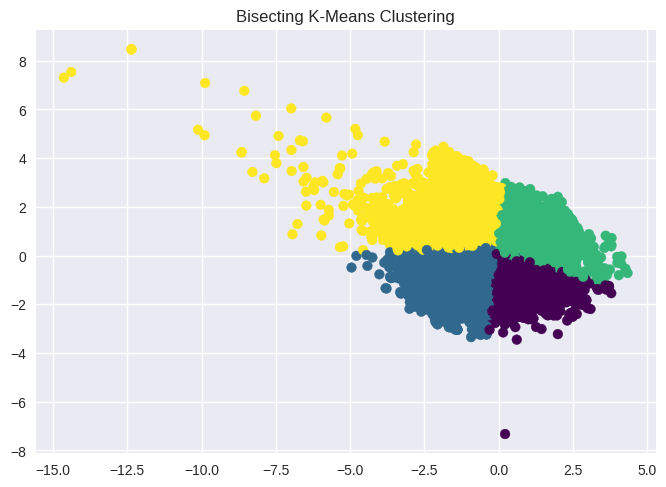

In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt

class BisectingKMeans:
    """Concise skeleton for students to implement a bisecting K-means algorithm."""

    def __init__(self, n_clusters, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.labels_ = None
        self.split_tree = {}
        self.centers_ = {}

    def fit_predict(self, X):
        n_samples = X.shape[0]

        # Start: all samples in cluster 0
        labels = np.zeros(n_samples, dtype=int)
        current_clusters = {0: np.arange(n_samples)}
        next_label = 1  # next new cluster id

        # Keep splitting until desired clusters reached
        while len(current_clusters) < self.n_clusters:

            # Pick the *largest* cluster to split
            cluster_to_split = max(current_clusters, key=lambda c: len(current_clusters[c]))
            indices = current_clusters[cluster_to_split]
            subset = X[indices]

            # Binary K-Means
            km = KMeans(n_clusters=2, random_state=self.random_state)
            split_labels = km.fit_predict(subset)

            # New child labels
            left_child = cluster_to_split
            right_child = next_label
            next_label += 1

            # Assign new labels globally
            labels[indices[split_labels == 0]] = left_child
            labels[indices[split_labels == 1]] = right_child

            # Update cluster dictionary
            del current_clusters[cluster_to_split]
            current_clusters[left_child] = indices[split_labels == 0]
            current_clusters[right_child] = indices[split_labels == 1]

            # Store split metadata
            self.split_tree[cluster_to_split] = (left_child, right_child)

            # Save centroids
            self.centers_[left_child] = km.cluster_centers_[0]
            self.centers_[right_child] = km.cluster_centers_[1]

        self.labels_ = labels

        score = silhouette_score(X, labels)
        print(f"Silhouette Score (Bisecting K-Means): {score:.4f}")

        return labels


# Example usage:
bisect = BisectingKMeans(n_clusters=4)
labels = bisect.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis")
plt.title("Bisecting K-Means Clustering")
plt.show()


## Bonus Challenges

If you've completed the main tasks, try these extensions:

1. Implement k-means++ initialization
   - Instead of random initialization, use the k-means++ algorithm
   - This should give better and more consistent results

2. Add cluster interpretation
   - Analyze the characteristics of each cluster
   - What features distinguish one cluster from another?
   - Create visualizations to show cluster properties

3. Try different distance metrics
   - Implement Manhattan distance instead of Euclidean
   - Compare the clustering results

4. Add outlier detection
   - Identify points far from all centroids
   - How might you handle these outliers?

Remember to document your code and explain your findings!

Bonus: k-means++ initializer ready.


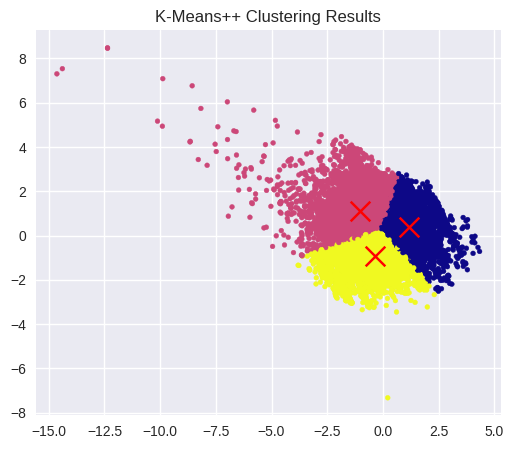

In [94]:
def kmeans_plus_plus_init(X, k, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    # 1. Pick first centroid randomly
    centroids = [X[np.random.choice(n_samples)]]

    # 2. Pick remaining k-1 centroids
    for _ in range(1, k):
        # Distances to nearest centroid
        distances = np.min(np.linalg.norm(X[:, None] - np.array(centroids), axis=2), axis=1)
        probs = distances**2 / np.sum(distances**2)
        new_centroid = X[np.random.choice(n_samples, p=probs)]
        centroids.append(new_centroid)

    return np.array(centroids)

print("Bonus: k-means++ initializer ready.")

centroids_pp = kmeans_plus_plus_init(X_pca, 3)

model_pp = KMeansClustering(n_clusters=3)
model_pp.centroids = centroids_pp
model_pp.fit(X_pca)
labels_pp = model_pp.labels

# Plot
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pp, cmap='plasma', s=12)
plt.scatter(model_pp.centroids[:,0], model_pp.centroids[:,1], c='red', s=200, marker='x')
plt.title("K-Means++ Clustering Results")
plt.show()


Bonus: cluster interpretation ready.

Cluster Sizes:


,count
cluster,
2,19259
0,15411
1,10541



Cluster Feature Means:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
cluster,,,,,,,,,,,,,,,,,
0,39.375316,1.725715,1.122964,0.755694,0.037895,691.043605,0.835118,0.290572,0.809097,15.418532,6.176562,257.471546,2.662773,46.513464,0.554409,2.533255,0.072156
1,52.785220,4.522911,0.937482,1.108718,0.000000,2937.094298,0.131107,0.065648,0.577459,16.016981,4.921734,260.448914,2.810360,27.331468,0.469595,2.661038,0.159567
2,35.699932,6.331274,1.329560,1.663742,0.011994,1037.442131,0.564827,0.107690,0.539488,16.001558,5.329145,257.465341,2.819253,42.186199,0.661665,2.526040,0.129550


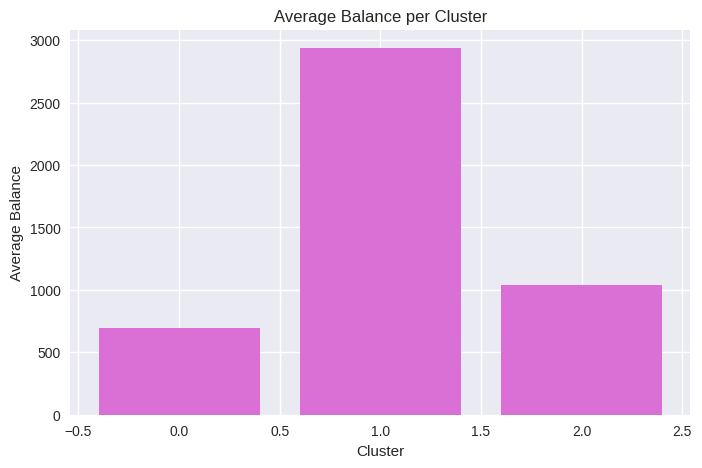

In [95]:
def interpret_clusters(df, labels):
    df2 = df.copy()
    df2["cluster"] = labels

    print("\nCluster Sizes:")
    display(df2["cluster"].value_counts())

    print("\nCluster Feature Means:")
    display(df2.groupby("cluster").mean())

print("Bonus: cluster interpretation ready.")

interpret_clusters(data, kmeans.labels)

# Bar plot of mean features per cluster (example: balance)
plt.figure(figsize=(8,5))
cluster_means = data.copy()
cluster_means["cluster"] = kmeans.labels

balance_means = cluster_means.groupby("cluster")["balance"].mean()
plt.bar(balance_means.index, balance_means.values, color='orchid')
plt.title("Average Balance per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Balance")
plt.show()



Bonus: Manhattan distance function ready.


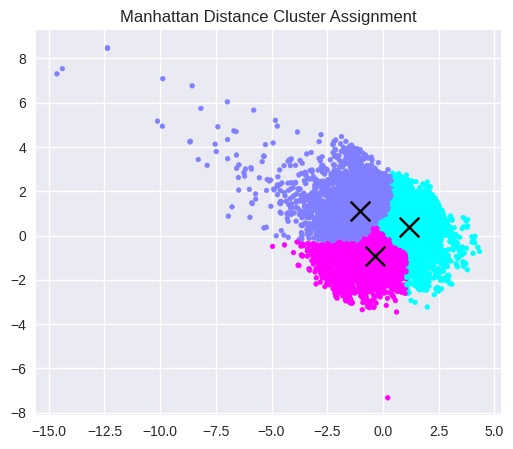

Silhouette Score (Manhattan): 0.37816961658837656


In [96]:
def manhattan_assign(X, centroids):
    """Return labels using Manhattan distance."""
    distances = np.sum(np.abs(X[:, None] - centroids), axis=2)
    return np.argmin(distances, axis=1)

print("Bonus: Manhattan distance function ready.")

labels_manhattan = manhattan_assign(X_pca, kmeans.centroids)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_manhattan, cmap='cool', s=12)
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], c='black', s=200, marker='x')
plt.title("Manhattan Distance Cluster Assignment")
plt.show()

print("Silhouette Score (Manhattan):", silhouette_score(X_pca, labels_manhattan))

In [97]:
def detect_outliers(X, centroids, labels, threshold=3.0):
    """
    Detect points whose distance from their centroid is > mean + threshold*std.
    """
    distances = np.linalg.norm(X - centroids[labels], axis=1)
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)

    cutoff = mean_dist + threshold * std_dist
    outliers = np.where(distances > cutoff)[0]

    return outliers, distances

print("Bonus: outlier detection ready.")


Bonus: outlier detection ready.


Bonus: outlier visualization ready.
Number of outliers detected: 478
Outlier indices (first 20): [ 354  446  572  920 1588 1653 1814 1822 2046 2113 2387 2554 2619 2719
 2754 2778 2848 3024 3197 3288]


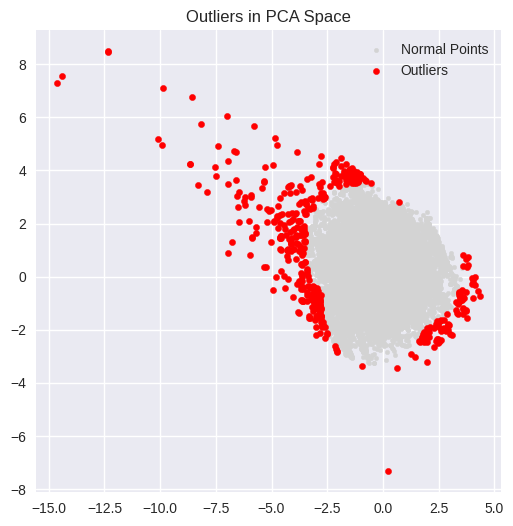

In [98]:
def plot_outliers(X_pca, outliers):
    plt.figure(figsize=(6,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], s=10, c="lightgray", label="Normal Points")
    plt.scatter(X_pca[outliers,0], X_pca[outliers,1], s=20, c="red", label="Outliers")
    plt.title("Outliers in PCA Space")
    plt.legend()
    plt.show()

print("Bonus: outlier visualization ready.")

outliers, distances = detect_outliers(X_pca, kmeans.centroids, kmeans.labels)

print("Number of outliers detected:", len(outliers))
print("Outlier indices (first 20):", outliers[:20])

# Plot outliers
plot_outliers(X_pca, outliers)

